In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
data=pd.read_csv(r"D:\college\course projects\eda cp\data_ecommerce_customer_churn.csv")
data.count()

Tenure                      3747
WarehouseToHome             3772
NumberOfDeviceRegistered    3941
PreferedOrderCat            3941
SatisfactionScore           3941
MaritalStatus               3941
NumberOfAddress             3941
Complain                    3941
DaySinceLastOrder           3728
CashbackAmount              3941
Churn                       3941
dtype: int64

In [2]:
df=pd.DataFrame(data)
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [ ]:
#preprocessing

In [13]:
#median for numerical data
df['Tenure'].fillna(df['Tenure'].median(), inplace=True)
df['WarehouseToHome'].fillna(df['WarehouseToHome'].median(),inplace=True)
df['DaySinceLastOrder'].fillna(df['DaySinceLastOrder'].median(), inplace=True)
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,3.0,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [14]:
#dropping null values
df.dropna()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,3.0,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
...,...,...,...,...,...,...,...,...,...,...,...
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3938,30.0,6.0,5,Laptop & Accessory,3,Married,3,1,2.0,156.60,0
3939,6.0,14.0,4,Mobile,3,Married,10,1,0.0,124.37,1


In [ ]:
#visualisation

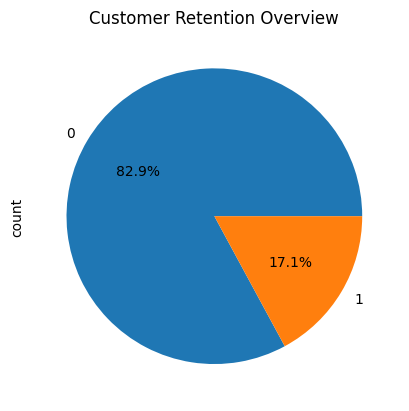

In [26]:
df['Churn'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title("Customer Retention Overview")
plt.show()
#Overview purposes

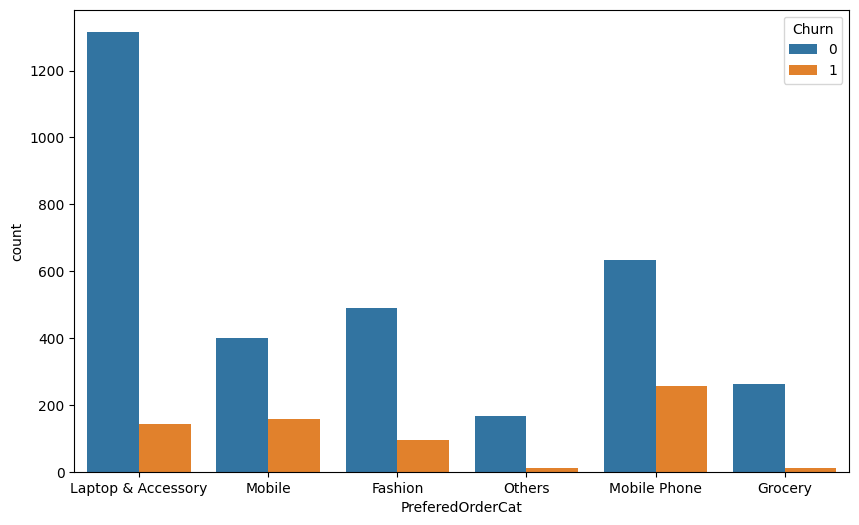

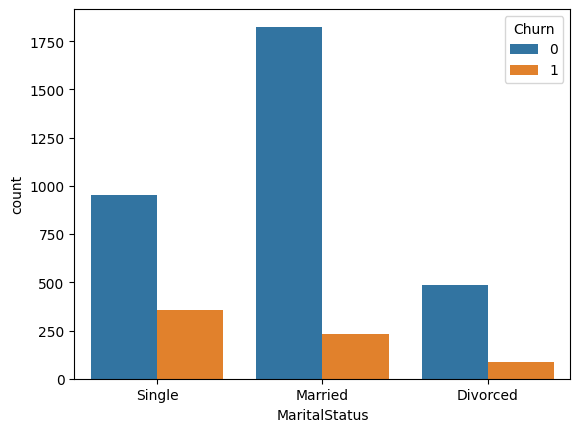

In [27]:
plt.figure(figsize=(10,6))
sns.countplot(x='PreferedOrderCat',hue='Churn',data=df)
plt.show()
sns.countplot(x='MaritalStatus',hue='Churn',data=df)
plt.show()

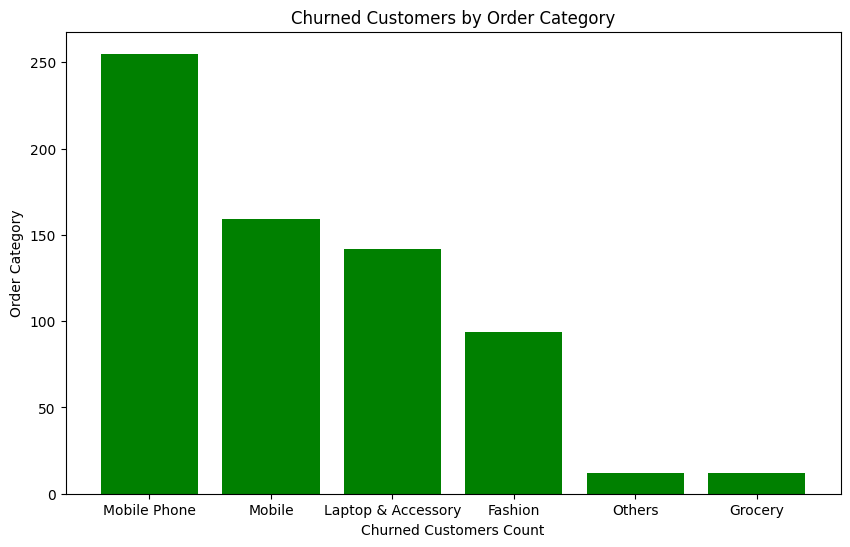

In [4]:
df=pd.DataFrame(data)
churncat=df[df['Churn']==1]['PreferedOrderCat'].value_counts()
plt.figure(figsize=(10,6))
plt.bar(churncat.index,churncat.values,color='green')
plt.xlabel("Churned Customers Count")
plt.ylabel("Order Category")
plt.title("Churned Customers by Order Category")
plt.show()
#To focus on a particular category

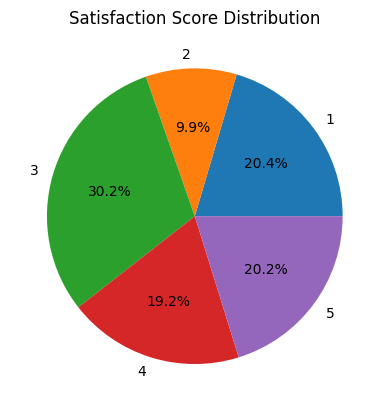

In [5]:
plt.figure()
score = df['SatisfactionScore'].value_counts().sort_index()
plt.pie(score.values,labels=score.index,autopct='%1.1f%%')
plt.title("Satisfaction Score Distribution")
plt.show()
#To understand user experience

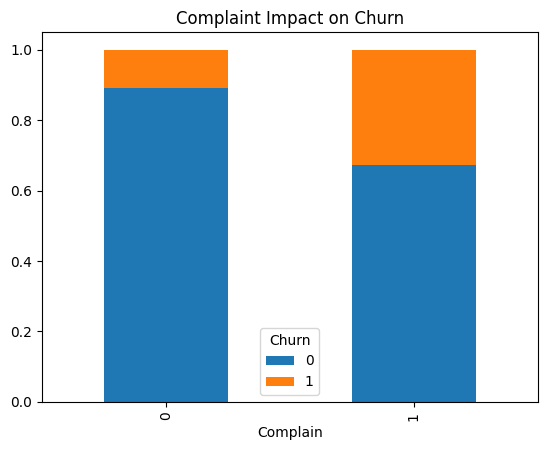

In [35]:
pd.crosstab(df['Complain'], df['Churn'], normalize='index').plot(kind='bar',stacked=True)
plt.title("Complaint Impact on Churn")
plt.show()
#tro understand correlation between user experience and customer support system

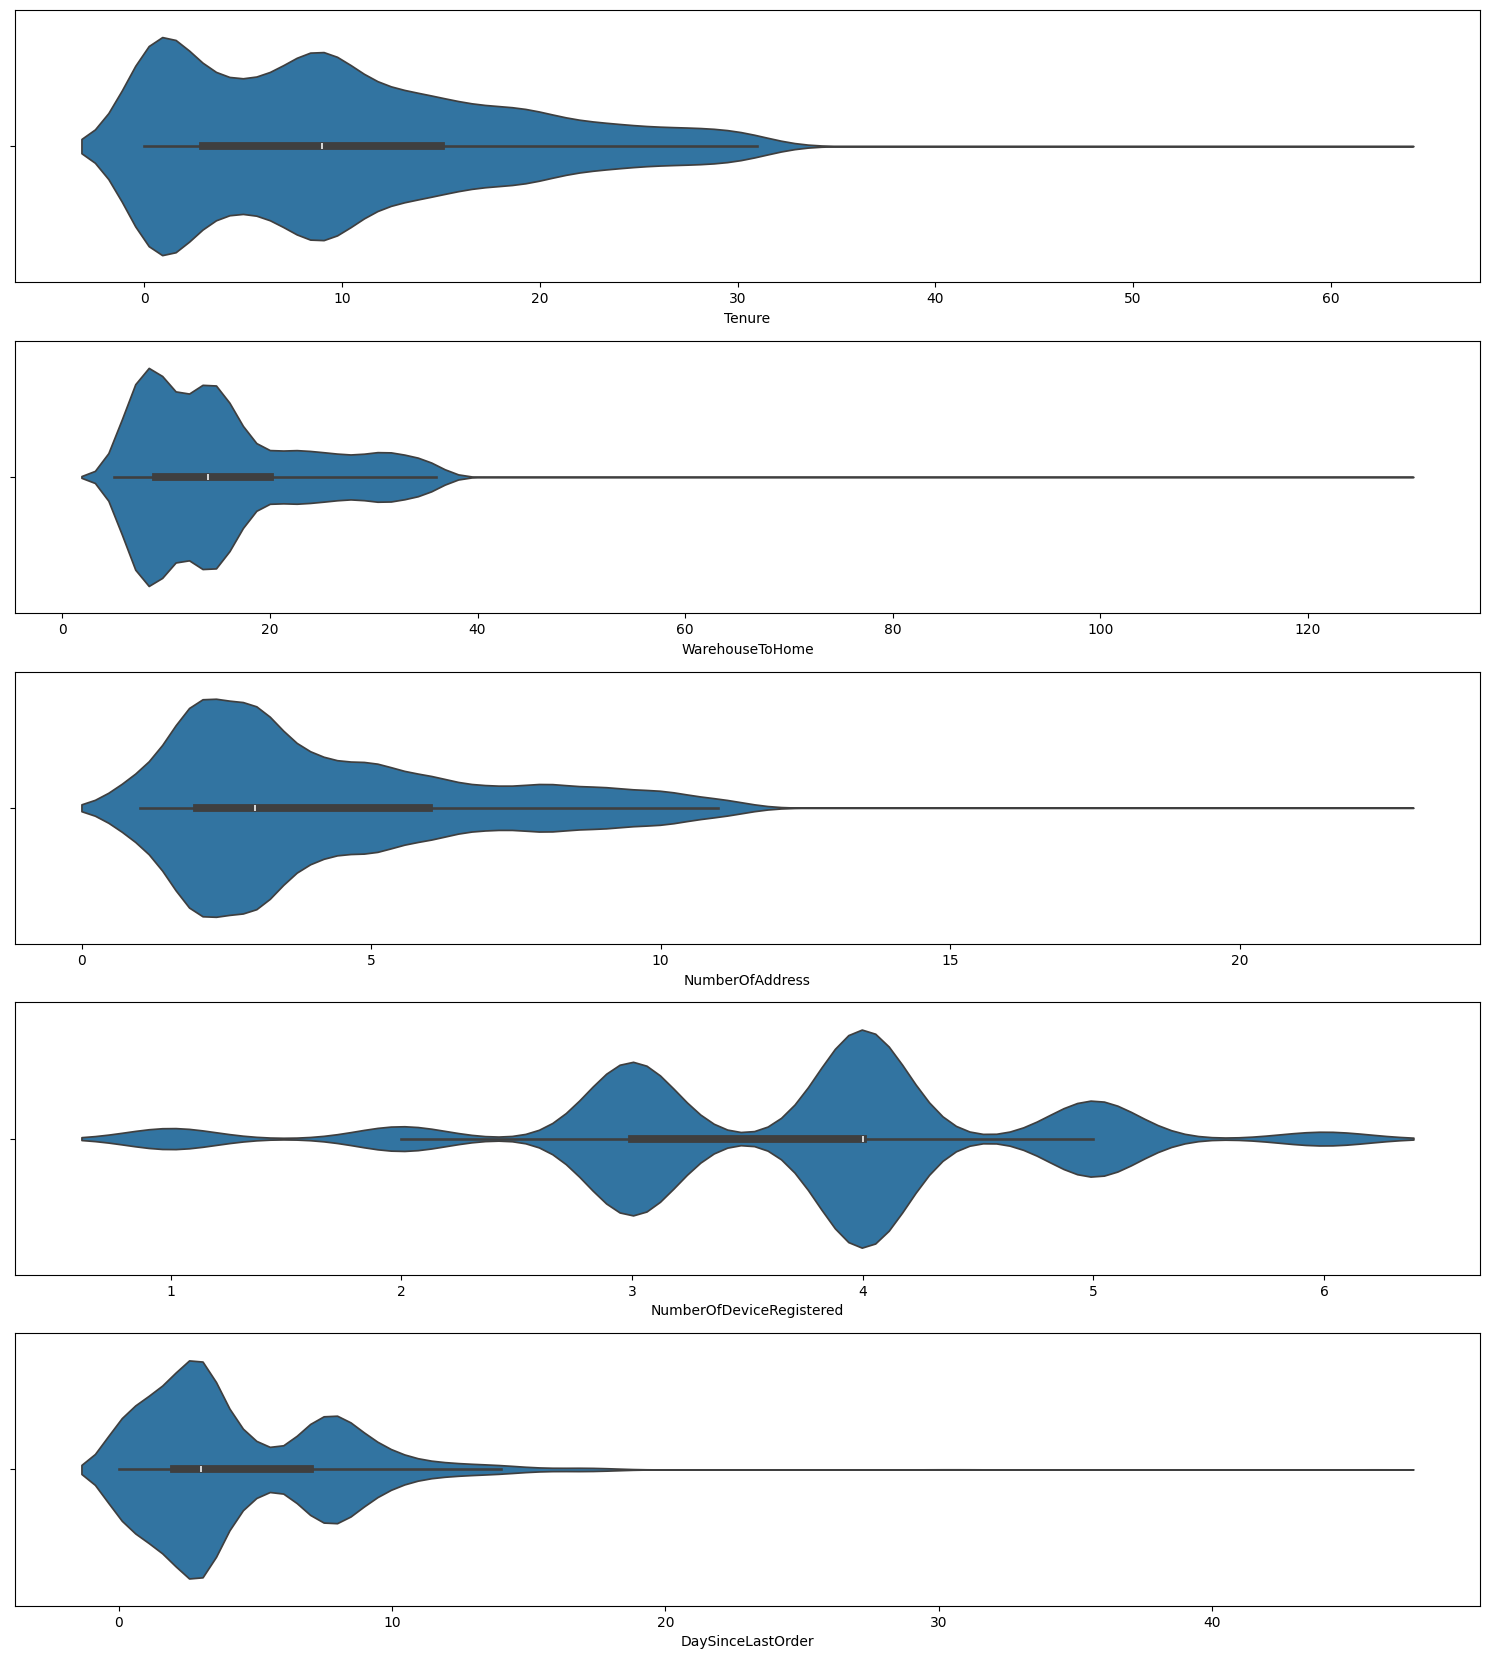

In [45]:
#distribution of data amongst numerical variables
#identification of outliers
num_vars = ['Tenure', 'WarehouseToHome', 'NumberOfAddress', 'NumberOfDeviceRegistered',
            'DaySinceLastOrder', 'CashbackAmount']

fig, axs = plt.subplots(nrows=6, ncols=1, figsize=(15, 20))
axs = axs.flatten()

for i, var in enumerate(num_vars):
    sns.violinplot(x=var, data=df, ax=axs[i])

fig.tight_layout()
fig.delaxes(axs[5])

plt.show()

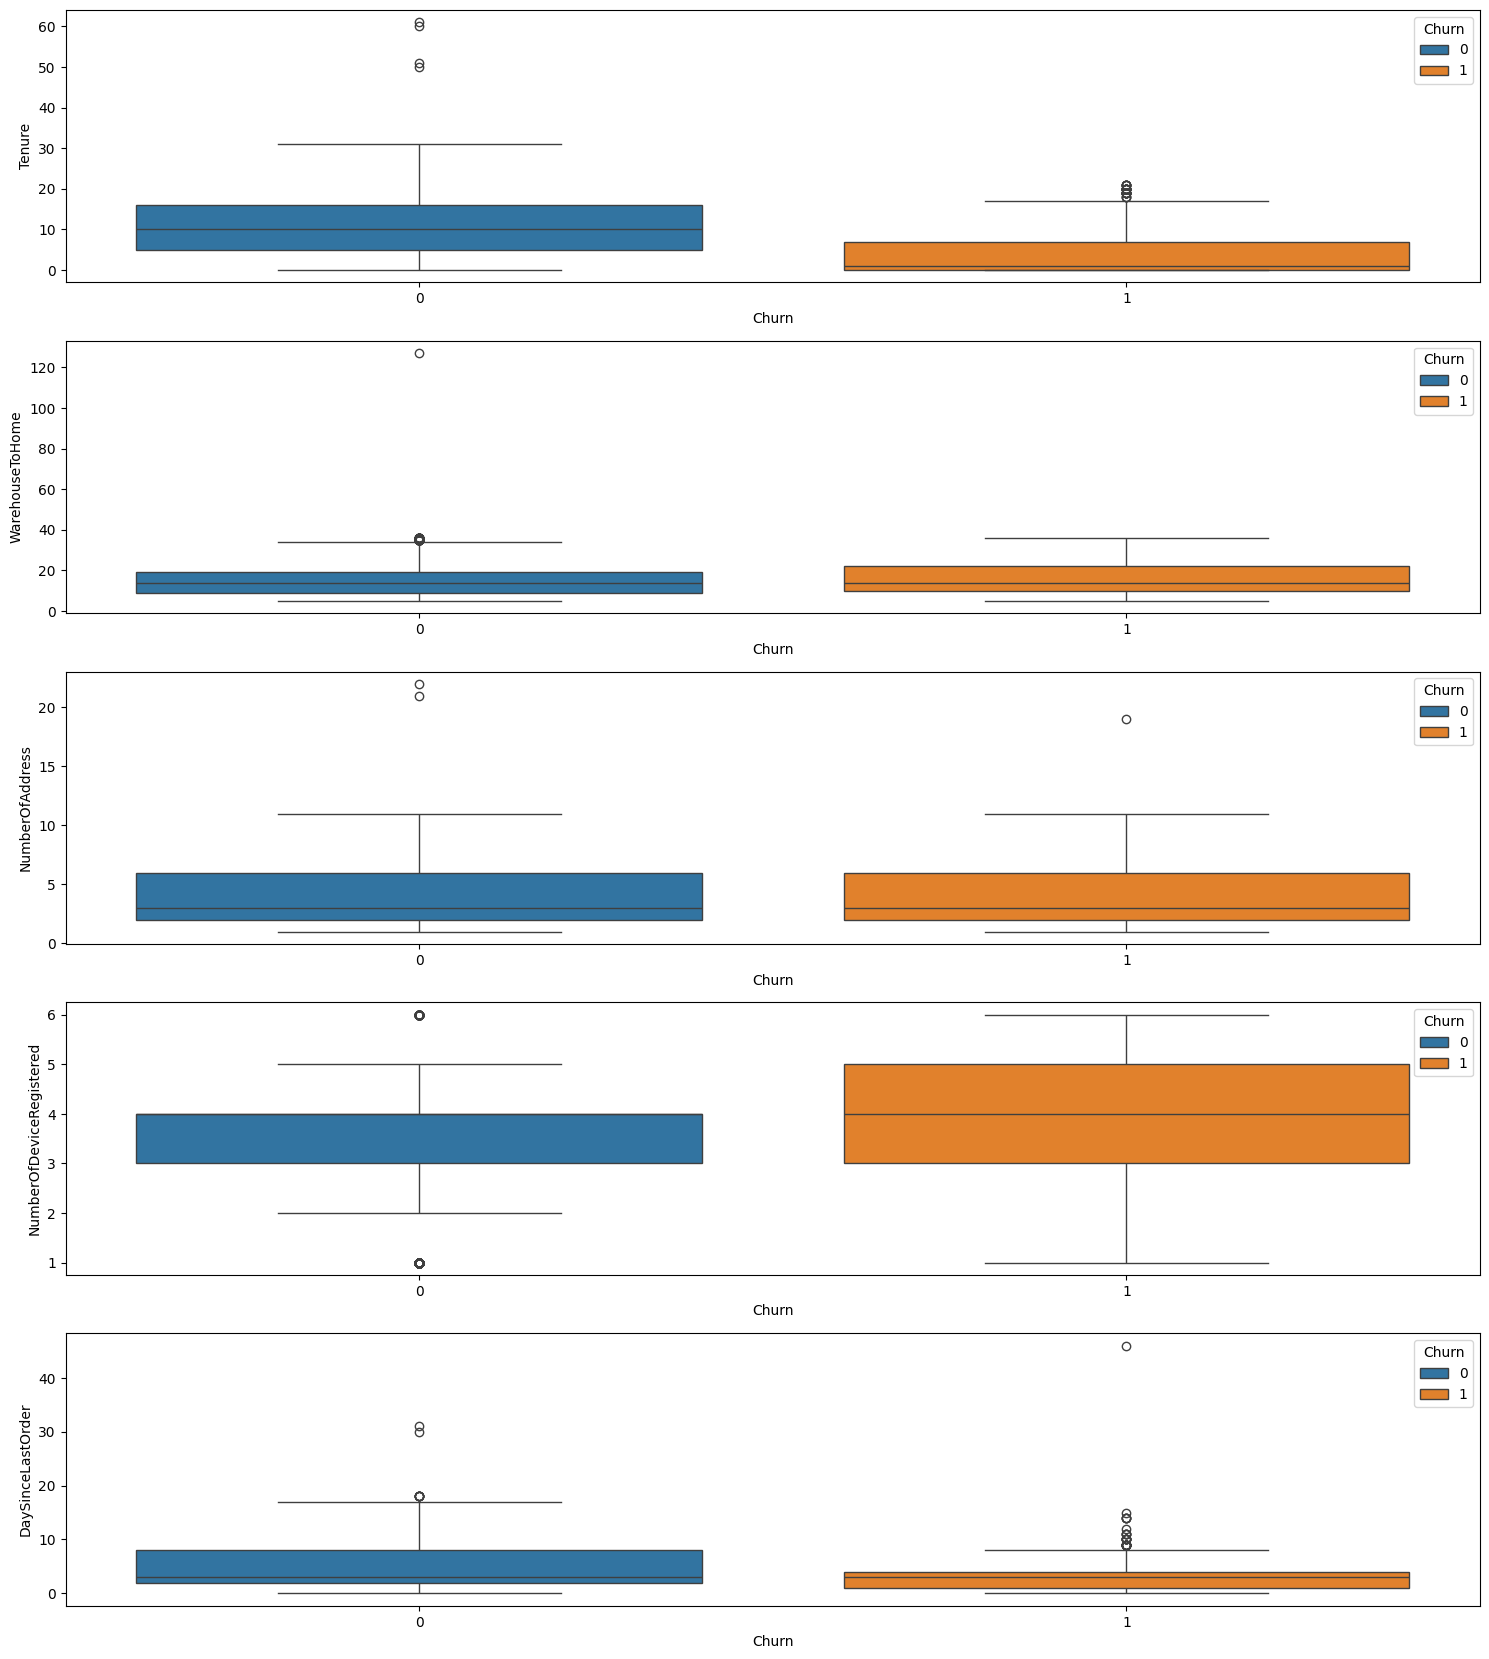

In [44]:
#previous data separated by churn
fig, axs = plt.subplots(nrows=6, ncols=1, figsize=(15, 20))
axs = axs.flatten()

for i, var in enumerate(num_vars):
    sns.boxplot(y=var,x='Churn', hue='Churn',data=df, ax=axs[i])

fig.tight_layout()
fig.delaxes(axs[5])

plt.show()

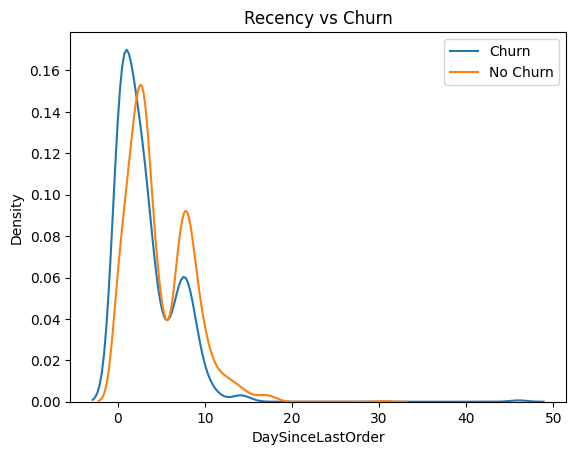

In [9]:
sns.kdeplot(df[df['Churn']==1]['DaySinceLastOrder'], label='Churn')
sns.kdeplot(df[df['Churn']==0]['DaySinceLastOrder'], label='No Churn')
plt.legend()
plt.title("Recency vs Churn")
plt.show()
#recent customers churn more likely
#churns have been more recent

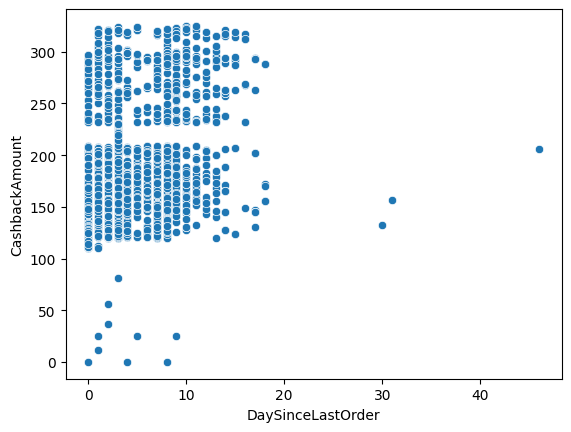

In [59]:
sns.scatterplot(x='DaySinceLastOrder', y='CashbackAmount', data=df)
plt.show()

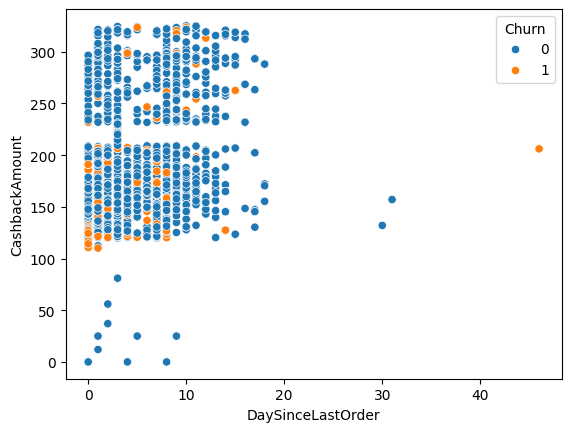

In [58]:
#previous data separated by churn
sns.scatterplot(x='DaySinceLastOrder', y='CashbackAmount', hue='Churn',data=df)
plt.show()

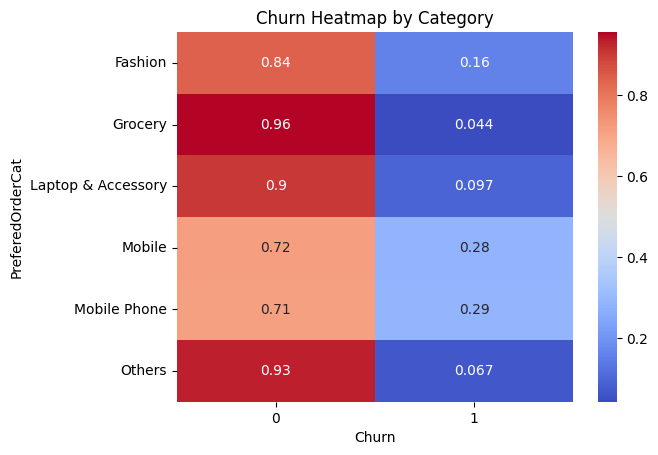

In [7]:
import seaborn as sns
sns.heatmap(
    pd.crosstab(df['PreferedOrderCat'], df['Churn'], normalize='index'),
    annot=True,
    cmap='coolwarm'
)
plt.title("Churn Heatmap by Category")
plt.show()
#categorical heatmap

In [66]:
from sklearn.model_selection import train_test_split
# Select the features (X) and the target variable (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
from sklearn.model_selection import train_test_split

# Select the column for outlier removal
selected_column = ['WarehouseToHome', 'DaySinceLastOrder', 'Tenure' ,
                   'NumberOfDeviceRegistered','NumberOfAddress']

# Split the data into training and test sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Calculate the z-scores for the selected column in the training set
train_z_scores = np.abs((train_df[selected_column] - train_df[selected_column].mean()) / train_df[selected_column].std())

# Set the threshold for defining outliers (e.g., z-score > 3)
threshold = 3

# Filter the training DataFrame, removing rows with z-scores above the threshold in the selected column
train_df_no_outliers = train_df[train_z_scores <= threshold]